In this notebook, various GBM's will be trained and blended in a parcymonious Logistic Regression

# Libraries & data

In [1]:
n_repeats, n_splits, seed, do_feat_imp = 3, 5, 666, False
n_repeats, n_splits, seed, do_feat_imp = 4, 8, 2025, False
n_repeats, n_splits, seed, do_feat_imp = 3, 10, 2001, False
n_repeats, n_splits, seed, do_feat_imp = 3, 10, 21, False
n_repeats, n_splits, seed, do_feat_imp = 4, 15, 21, False

import os
path = "/kaggle/input" if os.path.isdir("/kaggle/input/") else "."

cuda = False
if path == "/kaggle/input":
    import torch
    cuda = torch.cuda.is_available()
print(f"Is GPU/CUDA available : {cuda}")

output_path = "output"
if not os.path.exists(output_path):
    os.makedirs(output_path)

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 300)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn import set_config
set_config(transform_output="pandas")

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold

from sklearn.base import TransformerMixin, BaseEstimator

from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, StandardScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from catboost import CatBoostClassifier

from sklearn.metrics import roc_auc_score
def score_(y_true, y_pred):
    return roc_auc_score(y_true, y_pred)

from sklearn.linear_model import LogisticRegression

Is GPU/CUDA available : True


In [2]:
end = "\033[0m" # reset

bold       = "\033[1m" ; resetbold       = "\033[21m"
underline = "\033[4m"  ; resetunderline  = "\033[24m"
blink      = "\033[5m" ; resetblink      = "\033[25m"
reverse    = "\033[7m" ; resetreverse    = "\033[27m"

Default      = "\033[39m" ; Black        = "\033[30m" ; White        = "\033[97m"
Red          = "\033[31m" ; LightRed     = "\033[91m"
Green        = "\033[32m" ; LightGreen   = "\033[92m"
Yellow       = "\033[33m" ; LightYellow  = "\033[93m"
Blue         = "\033[34m" ; LightBlue    = "\033[94m"
Magenta      = "\033[35m" ; LightMagenta = "\033[95m"
Cyan         = "\033[36m" ; LightCyan    = "\033[96m"
DarkGray     = "\033[90m" ; LightGray    = "\033[37m"

BackgroundDefault     = "\033[49m"  ; BackgroundBlack        = "\033[40m"
BackgroundRed         = "\033[41m"  ; BackgroundLightRed     = "\033[101m"
BackgroundGreen       = "\033[42m"  ; BackgroundLightGreen   = "\033[102m"
BackgroundYellow      = "\033[43m"  ; BackgroundLightYellow  = "\033[103m"
BackgroundBlue        = "\033[44m"  ; BackgroundLightBlue    = "\033[104m"
BackgroundMagenta     = "\033[45m"  ; BackgroundLightMagenta = "\033[105m"
BackgroundCyan        = "\033[46m"  ; BackgroundLightCyan    = "\033[106m"
BackgroundDarkGray    = "\033[100m" ; BackgroundLightGray    = "\033[47m"

bold_blue = bold + LightBlue

In [3]:
train = pd.read_csv(f'{path}/playground-series-s4e10/train.csv', index_col = 'id')#.sample(frac=.05)
test = pd.read_csv(f'{path}/playground-series-s4e10/test.csv', index_col = 'id')

origin = pd.read_csv(f"{path}/loan-approval-prediction/credit_risk_dataset.csv")
origin["id"] = np.arange(test.index.max() + 1, test.index.max() + 1 + origin.shape[0])
origin = origin.set_index("id")

target = [f for f in train.columns if f not in test.columns][0]
original_features = list(test.columns)

nans = [train[test.columns].isna().sum().sum(), origin[test.columns].isna().sum().sum(), test.isna().sum().sum()]
is_nans = np.sum(nans) > 0
    
print(f"Shape for {LightBlue}Train{end} {train.shape} and {LightBlue}Test{end} {test.shape}")
print(f"Nan values in {LightBlue}Train{end} : {nans[0]} | in {LightBlue}Test{end} : {nans[2]}")

print(f"Shape for {LightBlue}Origin{end} {origin.shape} | ", end='')
print(f"Nan values in {LightBlue}Origin{end} : {nans[1]}")

print(f"\nAvailable columns for training : \n  {list(test.columns)}")

display(train.head(5).style.set_caption("Train"))

Shape for Train (58645, 12) and Test (39098, 11)
Nan values in Train : 0 | in Test : 0
Shape for Origin (32581, 12) | Nan values in Origin : 4011

Available columns for training : 
  ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
id,,,,,,,,,,,,
0,37,35000,RENT,0.000000,EDUCATION,B,6000,11.490000,0.170000,N,14,0
1,22,56000,OWN,6.000000,MEDICAL,C,4000,13.350000,0.070000,N,2,0
2,29,28800,OWN,8.000000,PERSONAL,A,6000,8.900000,0.210000,N,10,0
3,30,70000,RENT,14.000000,VENTURE,B,12000,11.110000,0.170000,N,5,0
4,22,60000,RENT,2.000000,MEDICAL,A,6000,6.920000,0.100000,N,3,0


In [4]:
categorical_columns = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# Functions
## Feature importance

In [5]:
class FeatureImportance():
    
    def __init__(self, n_permutations = None, lib_metric = None, digit = 4):
        
        self.n_permutations = n_permutations
        self.lib_metric = lib_metric
        self.differences = {}
        self.digit = digit
        
        self.metric_max = ["Accuracy", "AUC", "Recall@20", "cohen_kappa_score", "auc", "f1", "R2", "QWK"]
        self.metric_min = ["Logloss", "rmse", "RMSE", "mae", "Balanced log loss", "RMSLE"]
        if lib_metric not in self.metric_max + self.metric_min:
            raise ValueError(f"Unknown lib_metric : {lib_metric}.")
        
    def append(self, feature, metric_value, metric_ref):
        
        if feature not in self.differences.keys():
            self.differences[feature] = []
            
        self.differences[feature].append(metric_value - metric_ref)
        
    def build_dataframe(self):
        
        if self.differences == {}: return
        
        df_diff = pd.DataFrame(self.differences).transpose()
        df_diff["mean"] = df_diff.mean(axis=1)
        df_diff.sort_values("mean", ascending = self.lib_metric in self.metric_max, inplace=True)
        
        return df_diff
        
    def plot(self, title="", remove_from_output = []):
        
        if self.differences == {}: return
        
        df_diff = self.build_dataframe()
        if len(remove_from_output)>0:
            df_diff = df_diff.loc[~df_diff.index.isin(remove_from_output)]
        
        fk = next(iter(self.differences))
        len_fk = len(self.differences[fk])
        
        fig, ax = plt.subplots(1, 2, figsize = (15, int(df_diff.shape[0] * 1/2)))
            
        ax[0].boxplot(df_diff[[c for c in range(len_fk)]][::-1].T,
                          vert=False, labels=df_diff.index[::-1])
        ax[0].axvline(x = 0, color = 'green')
        ax[0].set_xlabel(f"Distribution {self.lib_metric} difference after permutation of values")
            
        sns.barplot(x = "mean", y = df_diff.index, data = df_diff, ax = ax[1], color = "green")
        ax[1].bar_label(ax[1].containers[0], fmt = f'%.{self.digit}f', padding = 2)
        ax[1].set_xlabel(f"Mean {self.lib_metric} difference after permutation of values")
        ax[1].set_yticklabels([])
        ax[1].set_yticks([])
        
        for ax_ in ax:
            ax_.set_title(title)
            ax_.xaxis.set_ticks_position("top")
            ax_.xaxis.set_label_position('top')
            ax_.spines[["right", "bottom"]].set_visible(False)
        ax[1].spines[["left"]].set_visible(False)

## CV loop

In [6]:
def do_cv(train = train, target = target, other_data = None, features = test.columns, params = {}, digit = 5,
          enc = ColumnTransformer(transformers = [], remainder = "passthrough", verbose_feature_names_out = False).set_output(transform = "pandas"), 
          my_model = None, do_feat_imp = False, 
          folds = RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed), 
          split_with = target,
          label = "", metric_label = "AUC"):
    
    feat_imp = FeatureImportance(n_permutations = 2, lib_metric = metric_label)
    oof_scores, val_scores, trn_scores, best_iteration = [], [], [], []
    oofs = pd.Series(0.0, name = target, index = train.index)
    preds = pd.Series(0.0, name = target, index = test.index)
    
    history = {}
    
    for fold, (trn_idx, val_idx) in enumerate(folds.split(train, train[split_with])):
        
        if other_data is not None:
            X_trn = pd.concat([train[features].iloc[trn_idx], other_data[features]], axis=0)
            y_trn = pd.concat([train[target].iloc[trn_idx], other_data[target]], axis=0)
        else:
            X_trn, y_trn = train[features].iloc[trn_idx], train[target].iloc[trn_idx]
            
        X_val, y_val = train[features].iloc[val_idx], train[target].iloc[val_idx]
            
        if (fold) % n_splits == 0:
            oof = pd.Series(0.0, name = target, index = train.index)
            pred = pd.Series(0.0, name = target, index = test.index)
        
        # Training
        model = my_model(**params)
        if "early_stopping_round" in params.keys() or ("early_stopping_rounds" in params.keys()) or ('od_wait' in params.keys()):
            if isinstance(model, CatBoostClassifier):
                model.fit(enc.fit_transform(X_trn), y_trn, eval_set=[(enc.transform(X_val), y_val)], verbose = 200)
                best_iteration.append(model.get_best_iteration())
            elif isinstance(model, XGBClassifier):
                model.fit(enc.fit_transform(X_trn), y_trn, eval_set=[(enc.transform(X_val), y_val)], verbose = 200)
                best_iteration.append(model.best_iteration)
                history = model.evals_result()
            elif isinstance(model, LGBMClassifier):
                model.fit(enc.fit_transform(X_trn), y_trn, eval_set=[(enc.transform(X_val), y_val)], 
                          callbacks = [early_stopping(params["early_stopping_round"], verbose = False), log_evaluation(200)])
                best_iteration.append(model.best_iteration_)
            else: print("Error")
        else:
            if isinstance(model, CatBoostClassifier) or isinstance(model, XGBClassifier) or isinstance(model, LGBMClassifier):
                model.fit(enc.fit_transform(X_trn), y_trn, eval_set=[(enc.transform(X_trn), y_trn), (enc.transform(X_val), y_val)], verbose = 200)
                best_iteration.append(params["n_estimators"])
            else:
                model.fit(enc.fit_transform(X_trn), y_trn)

        # Score & prediction
        trn_scores.append(score_(y_trn, model.predict_proba(enc.transform(X_trn))[:, 1]))
        oof.iloc[val_idx] += model.predict_proba(enc.transform(X_val))[:, 1]
        if label != "":
            features_test = [f for f in features if f not in [target, "class", "target_transf"]]
            pred += model.predict_proba(enc.transform(test[features_test]))[:, 1] / n_splits
            
        val_scores.append(score_(y_val, oof.iloc[val_idx]))

        oofs.iloc[val_idx] += oof.iloc[val_idx] / n_repeats
        
        print(f"    Fold {fold + 1:2} : {metric_label} {val_scores[-1]:.{digit}f}", end="")
        print(f" | in train {trn_scores[-1]:.{digit}f}", end='')
        print(f' | Overfitting {trn_scores[-1] - val_scores[-1]:.{digit}f}', end="")
        if len(best_iteration) > 0:
            print(f' | Best iteration {best_iteration[-1]}')
        else:
            print()
            
        if (fold + 1) % n_splits == 0:
            oof_scores.append(score_(train[target], oof))
            print(f'  {bold}Repeat {(fold + 1 ) // n_splits:2} : OOF {metric_label} {bold_blue}{oof_scores[-1]:.{digit}f}{end} | ', end='')
            print(f'Mean {metric_label} {np.mean(val_scores[-n_splits:]):.{digit}f}({bold+Red}±{np.std(val_scores[-n_splits:]):.{digit}f}){end}) | ', end='')
            print(f'Cum {score_(train[target], oofs):.{digit}f}{end}')
            
            if label != "":
                oof.to_csv(f"{output_path}/oof_{label}_r{(fold + 1) // n_splits}.csv")
                pred.to_csv(f"{output_path}/pred_{label}_r{(fold + 1) // n_splits}.csv")
            preds += pred / n_repeats
        
        # Feature importance
        if do_feat_imp:
            for feat in list(enc.transform(X_trn).columns):
                for i in range(feat_imp.n_permutations):
                    df = X_val.copy()
                    if feat in X_trn.columns:
                        df[feat] = pd.Series(np.random.permutation(df[feat]), index=df.index).astype(X_val[feat].dtypes)
                        if feat in enc.transform(X_trn).columns:
                            feat_imp.append(feat, score_(y_val, model.predict_proba(enc.transform(df))[:, 1]), val_scores[-1])
                    else:
                        df = enc.transform(df)
                        df[feat] = pd.Series(np.random.permutation(df[feat]), index=df.index).astype(df[feat].dtypes)
                        feat_imp.append(feat, score_(y_val, model.predict_proba(df)[:, 1]), val_scores[-1])
    # end of loop
    
    print(f'OOF {metric_label} {bold_blue}{score_(train[target], oofs):.{digit}f}{end} | ', end='')
    print(f'Mean over OOF : {bold_blue}{np.mean(oof_scores):.{digit}f}{end}', end='')
    print(f'({bold+Red}±{np.std(oof_scores):.{digit}f}){end} | ', end='')
    print(f'Mean over folds : {np.mean(val_scores):.{digit}f}', end='')
    print(f'(±{np.std(val_scores):.{digit}f}) | ', end='')
    print(f'Overfitting : {np.mean(trn_scores)-np.mean(val_scores):.{digit}f}')
    if len(best_iteration)>0:
        print(f'Mean Best iteration {int(np.mean(best_iteration))}(±{int(np.std(best_iteration))}) | ', end='')
        print(f'Median Best iteration {np.median(best_iteration)}')
    
    feat_imp.plot()
    
    res = {'history':history, "val_scores" : val_scores, "feat_imp": feat_imp}
    
    if len(best_iteration) > 0:
        res.update({"mean_it":int(np.mean(best_iteration)), "median_it":np.median(best_iteration)})
    
    return res

## To categorical

In [7]:
class to_categorical_old(BaseEstimator, TransformerMixin):
    
    def __init__(self, features):
        
        self.features = features
        self.verbose = True
            
    def fit(self, X, y = None):
        
        return self
    
    
    def transform(self, X, y = None):
        
        df = X.copy()
        
        for f in self.features:
            df[f] = df[f].astype('category')
            
        return df

    
class to_string_old(BaseEstimator, TransformerMixin):
    
    def __init__(self, features):
        
        self.features = features
        self.verbose = True
            
    def fit(self, X, y = None):
        
        return self
    
    def transform(self, X, y = None):
        
        df = X.copy()
        
        df = df.fillna(0)

        for f in self.features:
            df[f] = df[f].astype('string')  
        
        return df

    
class my_FE(BaseEstimator, TransformerMixin):
    
    def __init__(self, features, verbose = True):
        
        self.features = features
        self.verbose = verbose
            
    def fit(self, X, y = None):
        
        return self
    
    def transform(self, X, y = None):
        
        df = X.copy()
        
        for f in self.features:
            df[f"{f}_2"] = df[f]
            
        return df

In [8]:
class to_categorical(BaseEstimator, TransformerMixin):
    
    def __init__(self, min_frequency = 10, unknown_value = -666):
        
        self.verbose = True
        self.min_frequency = min_frequency
        self.unknown_value = unknown_value
            
    def fit(self, X, y = None):
        
        df = X.copy()
        self.all_categ = {}
        self.transf = {}
        
        for f in df.columns:
            
            self.transf[f] = []
            vc = df[f].value_counts()
            for v in vc[vc < self.min_frequency].index:
                df.loc[df[f] == v, f] = self.unknown_value
                self.transf[f].append(v)
            
            self.all_categ[f] = df[f].astype("category").cat
            
            if self.unknown_value not in list(self.all_categ[f].categories):
                self.all_categ[f] = self.all_categ[f].add_categories([self.unknown_value]).cat

        return self
    
    
    def transform(self, X, y = None):
        
        df = X.copy()
        
        for f in df.columns:
            
            for v in self.transf[f]:
                df.loc[df[f] == v, f] = self.unknown_value
            
            df[f] = pd.Categorical(df[f], categories = self.all_categ[f].categories)
            
        return df
    
    
class to_string(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        
        self.verbose = True
            
    def fit(self, X, y = None):
        
        return self
    
    def transform(self, X, y = None):
        
        df = X.copy()
        
        for f in df.columns:
            df[f] = df[f].astype('string')  
        
        return df

# XGBoost

## XGB4

In [9]:
params = {
    'booster'               : 'gbtree',
    "tree_method"           : "hist",
    'objective'             : 'binary:logistic',#reg:squarederror', 
    'eval_metric'           : "auc",
    "device"                : "cuda" if cuda else "cpu",
    'verbosity'             : 0,
    "random_state"          : seed,
    'n_estimators'          : 2000, 'early_stopping_rounds' : 100,
    
    'learning_rate'         : .1,
    "enable_categorical"    : True,
    
    'alpha': 2.2381286517608854,
    'colsample_bytree': 0.3342647822321505,
    'lambda': 17.280123830073414,
    'max_bin': 262,
    'max_depth': 6,
}

features = [f for f in test.columns if f not in ['cb_person_default_on_file', 'cb_person_cred_hist_length']]

new_model = {
    'features'              : features,
    'my_model'              : XGBClassifier,
    'params'                : params,
    'other_data'            : origin,
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+1), 
    'enc'                   : make_pipeline(

        my_FE(features = ["person_income", "loan_int_rate", "loan_amnt"]),
    
        ColumnTransformer(transformers = [
            ("label_encoder", OrdinalEncoder(
                **{"handle_unknown":"use_encoded_value", 'unknown_value' : -666, 'encoded_missing_value':-665}
            ), features),
        ], remainder = "passthrough", verbose_feature_names_out = False),
    
        ColumnTransformer(transformers = [
            ("categorical", to_categorical(min_frequency = 5, unknown_value = -666), features),
        ], remainder = "passthrough", verbose_feature_names_out = False), 
        
    ),
    'do_feat_imp'           : do_feat_imp,
    'label'                 : "" if n_repeats == 1 else "xgb4",
}

res = do_cv(**new_model)

[0]	validation_0-auc:0.83234
[200]	validation_0-auc:0.96871
[400]	validation_0-auc:0.96907
[437]	validation_0-auc:0.96899
    Fold  1 : AUC 0.96923 | in train 0.98297 | Overfitting 0.01374 | Best iteration 337
[0]	validation_0-auc:0.81529
[200]	validation_0-auc:0.97172
[400]	validation_0-auc:0.97207
[438]	validation_0-auc:0.97199
    Fold  2 : AUC 0.97217 | in train 0.98252 | Overfitting 0.01034 | Best iteration 339
[0]	validation_0-auc:0.81744
[200]	validation_0-auc:0.96167
[385]	validation_0-auc:0.96194
    Fold  3 : AUC 0.96218 | in train 0.98129 | Overfitting 0.01911 | Best iteration 286
[0]	validation_0-auc:0.81270
[200]	validation_0-auc:0.96526
[400]	validation_0-auc:0.96617
[600]	validation_0-auc:0.96641
[677]	validation_0-auc:0.96640
    Fold  4 : AUC 0.96656 | in train 0.98771 | Overfitting 0.02115 | Best iteration 577
[0]	validation_0-auc:0.81296
[200]	validation_0-auc:0.96815
[400]	validation_0-auc:0.96936
[531]	validation_0-auc:0.96894
    Fold  5 : AUC 0.96943 | in train 0

# LightGBM

## LGBM10

In [10]:
params = {
    
    "boosting_type"         : 'gbdt', 
    'objective'             : "binary",
    "metric"                : "auc",
#    "device"                : "gpu" if cuda else "cpu",
    "n_jobs"                : -1,
    "verbose"               : -1,
    "random_state"          : seed,
    'n_estimators'          : 2000, "early_stopping_round": 100,
    
    'learning_rate'         : .1,

    'max_cat_to_onehot':7,
    'cat_l2': 26.179045353024094,
    'cat_smooth': 0.4764155213590713,
    'colsample_bytree': 0.4327323236566456,
    'min_child_samples': 284,
    'min_data_per_group': 72,
    'num_leaves': 31,
    'reg_alpha': 2.4201290004656815,
    'reg_lambda': 25.874468667015634,
    'subsample': 0.6479687945142715,

}

features = [f for f in test.columns if f not in ['cb_person_cred_hist_length', 'cb_person_default_on_file']]

new_model = {
    'do_feat_imp'           : do_feat_imp,
    'label'                 : "" if n_repeats == 1 else "lgbm10a",
    'features'              : features,
    'my_model'              : LGBMClassifier,
    'params'                : params,
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+10), 
    'other_data'            : origin,
    'enc'                   : make_pipeline(

        my_FE(features = ["person_income", "loan_int_rate", "loan_amnt"]),
    
        ColumnTransformer(transformers = [
            ("label_encoder", OrdinalEncoder(
                **{"handle_unknown":"use_encoded_value", 'unknown_value' : -666, 'encoded_missing_value':-665}
            ), features),
        ], remainder = "passthrough", verbose_feature_names_out = False),
    
        ColumnTransformer(transformers = [
            ("categorical", to_categorical(min_frequency = 2, unknown_value = -666), features),
        ], remainder = "passthrough", verbose_feature_names_out = False), 
        
    ),
}

res = do_cv(**new_model)

[200]	valid_0's auc: 0.974722
    Fold  1 : AUC 0.97486 | in train 0.98532 | Overfitting 0.01046 | Best iteration 182
[200]	valid_0's auc: 0.963279
[400]	valid_0's auc: 0.963123
    Fold  2 : AUC 0.96358 | in train 0.99261 | Overfitting 0.02904 | Best iteration 362
[200]	valid_0's auc: 0.966054
    Fold  3 : AUC 0.96647 | in train 0.99054 | Overfitting 0.02407 | Best iteration 295
[200]	valid_0's auc: 0.966912
    Fold  4 : AUC 0.96725 | in train 0.98946 | Overfitting 0.02222 | Best iteration 270
[200]	valid_0's auc: 0.963367
    Fold  5 : AUC 0.96364 | in train 0.98798 | Overfitting 0.02434 | Best iteration 235
[200]	valid_0's auc: 0.966306
    Fold  6 : AUC 0.96684 | in train 0.98348 | Overfitting 0.01664 | Best iteration 157
[200]	valid_0's auc: 0.968006
[400]	valid_0's auc: 0.96797
    Fold  7 : AUC 0.96845 | in train 0.99161 | Overfitting 0.02317 | Best iteration 335
[200]	valid_0's auc: 0.960195
    Fold  8 : AUC 0.96033 | in train 0.98659 | Overfitting 0.02627 | Best iteration 1

In [11]:
params = {
    
    "boosting_type"         : 'gbdt', #goss
    'objective'             : "binary",#'multiclass',
    "metric"                : "auc",
#    "device"                : "gpu" if cuda else "cpu",
    "n_jobs"                : -1,
    "verbose"               : -1,
    "random_state"          : seed,
    'n_estimators'          : 2000, "early_stopping_round": 100,
    
    'learning_rate'         : .1,

    'max_cat_to_onehot':7,

    'cat_l2': 26.45274213367932,
  'cat_smooth': 0.793745042045531,
  'colsample_bytree': 0.4366038854442565,
  'min_child_samples': 242,
  'min_data_per_group': 223,
  'num_leaves': 36,
  'reg_alpha': 2.93028406792215,
  'reg_lambda': 23.667280676187485,
  'subsample': 0.6540889660987311,

}

features = [f for f in test.columns if f not in ['cb_person_cred_hist_length', 'cb_person_default_on_file']]

new_model = {
    'do_feat_imp'           : do_feat_imp,
    'label'                 : "" if n_repeats == 1 else "lgbm10b",
    'features'              : features,
    'my_model'              : LGBMClassifier,
    'params'                : params,
    'other_data'            : origin,
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+20), 
    'enc'                   : make_pipeline(

        my_FE(features = ["person_income", "loan_int_rate", "loan_amnt"]),
    
        ColumnTransformer(transformers = [
            ("label_encoder", OrdinalEncoder(
                **{"handle_unknown":"use_encoded_value", 'unknown_value' : -666, 'encoded_missing_value':-665}
            ), features),
        ], remainder = "passthrough", verbose_feature_names_out = False),
    
        ColumnTransformer(transformers = [
            ("categorical", to_categorical(min_frequency = 2, unknown_value = -666), features),
        ], remainder = "passthrough", verbose_feature_names_out = False), 
        
    ),
}

res = do_cv(**new_model)

    Fold  1 : AUC 0.96874 | in train 0.97251 | Overfitting 0.00377 | Best iteration 57
    Fold  2 : AUC 0.96019 | in train 0.98026 | Overfitting 0.02007 | Best iteration 98
[200]	valid_0's auc: 0.96352
    Fold  3 : AUC 0.96407 | in train 0.98628 | Overfitting 0.02221 | Best iteration 169
[200]	valid_0's auc: 0.966398
[400]	valid_0's auc: 0.966548
    Fold  4 : AUC 0.96702 | in train 0.99336 | Overfitting 0.02634 | Best iteration 316
[200]	valid_0's auc: 0.972464
    Fold  5 : AUC 0.97262 | in train 0.98858 | Overfitting 0.01596 | Best iteration 205
[200]	valid_0's auc: 0.967836
    Fold  6 : AUC 0.96849 | in train 0.98154 | Overfitting 0.01305 | Best iteration 111
[200]	valid_0's auc: 0.966016
    Fold  7 : AUC 0.96620 | in train 0.98635 | Overfitting 0.02016 | Best iteration 169
[200]	valid_0's auc: 0.970333
    Fold  8 : AUC 0.97100 | in train 0.99179 | Overfitting 0.02079 | Best iteration 281
[200]	valid_0's auc: 0.9744
[400]	valid_0's auc: 0.974446
    Fold  9 : AUC 0.97494 | in 

## LGBM9

In [12]:
params = {
    
    "boosting_type"         : 'gbdt', #goss
    'objective'             : "binary",#'multiclass',
    "metric"                : "auc",
#    "device"                : "gpu" if cuda else "cpu",
    "n_jobs"                : -1,
    "verbose"               : -1,
    "random_state"          : seed,
    'n_estimators'          : 2000, "early_stopping_round": 100,
    
    'learning_rate'         : .1,
    
    'cat_l2': 0.9471215190166176,
    'cat_smooth': 0.4311882995322439,
    'colsample_bytree': 0.42586048045158115,
    'min_child_samples': 132,
    'min_data_per_group': 118,
    'num_leaves': 31,
    'reg_alpha': 4.99556875016362,
    'reg_lambda': 26.66377704515293,
    'subsample': 0.8431717698708862

}

features = [f for f in test.columns if f not in ['cb_person_cred_hist_length', 'cb_person_default_on_file']]

new_model = {
    'do_feat_imp'           : do_feat_imp,
    'label'                 : "" if n_repeats == 1 else "lgbm9b",
    'features'              : features,
    'my_model'              : LGBMClassifier,
    'params'                : params,
    'other_data'            : origin,
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+30), 
    'enc'                   : make_pipeline(

        my_FE(features = ["person_income", "loan_int_rate", "loan_amnt"]),
    
        ColumnTransformer(transformers = [
            ("label_encoder", OrdinalEncoder(
                **{"handle_unknown":"use_encoded_value", 'unknown_value' : -666, 'encoded_missing_value':-665}
            ), features),
        ], remainder = "passthrough", verbose_feature_names_out = False),
    
        ColumnTransformer(transformers = [
            ("categorical", to_categorical(min_frequency = 2, unknown_value = -666), features),
        ], remainder = "passthrough", verbose_feature_names_out = False), 
        
    ),
}

res = do_cv(**new_model)

[200]	valid_0's auc: 0.963303
    Fold  1 : AUC 0.96368 | in train 0.99096 | Overfitting 0.02728 | Best iteration 266
[200]	valid_0's auc: 0.964141
[400]	valid_0's auc: 0.964082
    Fold  2 : AUC 0.96436 | in train 0.99279 | Overfitting 0.02844 | Best iteration 317
[200]	valid_0's auc: 0.969308
    Fold  3 : AUC 0.96955 | in train 0.98916 | Overfitting 0.01960 | Best iteration 229
[200]	valid_0's auc: 0.971036
    Fold  4 : AUC 0.97135 | in train 0.98548 | Overfitting 0.01413 | Best iteration 161
[200]	valid_0's auc: 0.966484
[400]	valid_0's auc: 0.966668
    Fold  5 : AUC 0.96699 | in train 0.99375 | Overfitting 0.02676 | Best iteration 348
[200]	valid_0's auc: 0.963228
    Fold  6 : AUC 0.96324 | in train 0.98830 | Overfitting 0.02506 | Best iteration 199
[200]	valid_0's auc: 0.972595
    Fold  7 : AUC 0.97291 | in train 0.98533 | Overfitting 0.01242 | Best iteration 158
[200]	valid_0's auc: 0.960275
    Fold  8 : AUC 0.96071 | in train 0.98510 | Overfitting 0.02439 | Best iteration 

## LGBM8

In [13]:
params = {
    
    "boosting_type"         : 'gbdt', #goss
    'objective'             : "binary",#'multiclass',
    "metric"                : "auc",
#    "device"                : "gpu" if cuda else "cpu",
    "n_jobs"                : -1,
    "verbose"               : -1,
    "random_state"          : seed,
    'n_estimators'          : 2000, "early_stopping_round": 100,
    
    'learning_rate'         : .1,
    
    'colsample_bytree': 0.4015159511557205,
  'min_child_samples': 259,
  'min_data_per_group': 236,
  'num_leaves': 26,
  'reg_alpha': 1.6864648834795928,
  'reg_lambda': 13.300544691112053,
  'subsample': 0.5063844131707592,
}

features = [f for f in test.columns if f not in ['cb_person_cred_hist_length', 'cb_person_default_on_file']]

new_model = {
    'do_feat_imp'           : do_feat_imp,
    'label'                 : "" if n_repeats == 1 else "lgbm8b",
    'features'              : features,
    'my_model'              : LGBMClassifier,
    'params'                : params,
    'other_data'            : origin,
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+40), 
    'enc'                   : make_pipeline(

        my_FE(features = ["person_income", "loan_int_rate", "loan_amnt"]),
    
        ColumnTransformer(transformers = [
            ("label_encoder", OrdinalEncoder(
                **{"handle_unknown":"use_encoded_value", 'unknown_value' : -666, 'encoded_missing_value':-665}
            ), features),
        ], remainder = "passthrough", verbose_feature_names_out = False),
    
        ColumnTransformer(transformers = [
            ("categorical", to_categorical(min_frequency = 2, unknown_value = -666), features),
        ], remainder = "passthrough", verbose_feature_names_out = False), 
        
    ),
}

res = do_cv(**new_model)

[200]	valid_0's auc: 0.973252
    Fold  1 : AUC 0.97383 | in train 0.98204 | Overfitting 0.00821 | Best iteration 160
[200]	valid_0's auc: 0.961216
    Fold  2 : AUC 0.96144 | in train 0.98912 | Overfitting 0.02768 | Best iteration 258
[200]	valid_0's auc: 0.968781
    Fold  3 : AUC 0.96900 | in train 0.98492 | Overfitting 0.01591 | Best iteration 189
[200]	valid_0's auc: 0.967249
    Fold  4 : AUC 0.96771 | in train 0.98399 | Overfitting 0.01627 | Best iteration 180
[200]	valid_0's auc: 0.965687
    Fold  5 : AUC 0.96628 | in train 0.98201 | Overfitting 0.01573 | Best iteration 154
[200]	valid_0's auc: 0.968443
    Fold  6 : AUC 0.96892 | in train 0.98860 | Overfitting 0.01969 | Best iteration 251
[200]	valid_0's auc: 0.972833
    Fold  7 : AUC 0.97347 | in train 0.98837 | Overfitting 0.01490 | Best iteration 248
[200]	valid_0's auc: 0.965788
    Fold  8 : AUC 0.96598 | in train 0.98193 | Overfitting 0.01595 | Best iteration 155
[200]	valid_0's auc: 0.959635
    Fold  9 : AUC 0.96031 

# Catboost

## CB11

In [14]:
features = [f for f in test.columns if f not in ['cb_person_default_on_file', 'cb_person_cred_hist_length']]
categorical_features = [f for f in categorical_columns if f in features]
do_not_convert_to_string = []# ["person_income"]#, "loan_amnt", "loan_int_rate"]

#convert_to_string = [f for f in features if f not in categorical_features]
convert_to_string = [f for f in features if f not in categorical_features+do_not_convert_to_string]

params={
    'task_type'             : "GPU" if cuda else "CPU",
    'loss_function'         : 'Logloss',
    'eval_metric'           : 'AUC',
    
    'score_function'        : 'NewtonL2',
    'verbose'               : 200,
    'iterations'            : 1500, "od_wait": 100,
    'random_state'          : seed,

    'learning_rate'         : 0.2, 
    'cat_features'          : [f for f in features if f not in do_not_convert_to_string], 

     'grow_policy'         : "Depthwise", 
    
    'bagging_temperature': 0.7290451305514561,
    'depth': 5,
    'l2_leaf_reg': 12.653123287061048,
    'min_data_in_leaf': 51,
    'random_strength': 4.3440282577441955
    
}

new_model = {
    'features'              : features,
    'my_model'              : CatBoostClassifier,
    'params'                : params,
    'other_data'            : origin,
    'enc'                   : make_pipeline(my_FE(features = ["person_income", "loan_percent_income", "loan_int_rate"]), to_string_old(convert_to_string), to_categorical_old(categorical_features)),
    'do_feat_imp'           : do_feat_imp,
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+90), 
    'label'                 : "" if n_repeats == 1 else "cb11c"
}

res = do_cv(**new_model)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9332123	best: 0.9332123 (0)	total: 4.46s	remaining: 1h 51m 32s
200:	test: 0.9596080	best: 0.9598211 (106)	total: 7.42s	remaining: 47.9s
bestTest = 0.959821105
bestIteration = 106
Shrink model to first 107 iterations.
    Fold  1 : AUC 0.95982 | in train 0.97673 | Overfitting 0.01691 | Best iteration 106


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9319476	best: 0.9319476 (0)	total: 16.4ms	remaining: 24.6s
200:	test: 0.9620416	best: 0.9620870 (171)	total: 3.07s	remaining: 19.9s
bestTest = 0.9623478055
bestIteration = 209
Shrink model to first 210 iterations.
    Fold  2 : AUC 0.96235 | in train 0.98022 | Overfitting 0.01787 | Best iteration 209


Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.9265344	best: 0.9265344 (0)	total: 14.2ms	remaining: 21.3s
200:	test: 0.9652336	best: 0.9652615 (169)	total: 2.82s	remaining: 18.2s
400:	test: 0.9647400	best: 0.9659250 (328)	total: 5.7s	remaining: 15.6s
bestTest = 0.9659249783
bestIteration = 328
Shrink model to first 329 iterations.
    Fold 58 : AUC 0.96592 | in train 0.98348 | Overfitting 0.01756 | Best iteration 328


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9495883	best: 0.9495883 (0)	total: 14.1ms	remaining: 21.2s
200:	test: 0.9688687	best: 0.9689712 (159)	total: 2.98s	remaining: 19.2s
bestTest = 0.9692378044
bestIteration = 255
Shrink model to first 256 iterations.
    Fold 59 : AUC 0.96924 | in train 0.98130 | Overfitting 0.01206 | Best iteration 255


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9418509	best: 0.9418509 (0)	total: 16.5ms	remaining: 24.7s
200:	test: 0.9699931	best: 0.9700944 (191)	total: 2.85s	remaining: 18.4s
bestTest = 0.9701368213
bestIteration = 210
Shrink model to first 211 iterations.
    Fold 60 : AUC 0.97014 | in train 0.97990 | Overfitting 0.00976 | Best iteration 210
  Repeat  4 : OOF AUC 0.96808 | Mean AUC 0.96826(±0.00467)) | Cum 0.96913
OOF AUC 0.96913 | Mean over OOF : 0.96811(±0.00003) | Mean over folds : 0.96823(±0.00421) | Overfitting : 0.01012
Mean Best iteration 173(±96) | Median Best iteration 153.0


## CB10
Optuna v33

In [15]:
features = [f for f in test.columns if f not in ['cb_person_default_on_file', 'cb_person_cred_hist_length']]
categorical_features = [f for f in categorical_columns if f in features]

convert_to_string = [f for f in features if f not in categorical_features]

params={
    'task_type'             : "GPU" if cuda else "CPU",
    'loss_function'         : 'Logloss',
    'eval_metric'           : 'AUC',
    
    'score_function'        : 'NewtonL2',
    'verbose'               : 200,
    'iterations'            : 1500, "od_wait": 100,
    'random_state'          : seed,

    'learning_rate'         : 0.2, 
    'cat_features'          : features,
    
    'bagging_temperature': 0.4063995212707797,
    'depth': 7,
    'l2_leaf_reg': 22.407966737693247,
    'min_data_in_leaf': 39,
    'random_strength': 0.10323107777746432
}

new_model = {
    'features'              : features,
    'my_model'              : CatBoostClassifier,
    'params'                : params,
    'other_data'            : origin,
    'enc'                   : make_pipeline(my_FE(features = ["person_income", "loan_percent_income", "loan_int_rate"]), to_string_old(convert_to_string), to_categorical_old(categorical_features)),
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+50), 
    'do_feat_imp'           : do_feat_imp,
    'label'                 : "" if n_repeats == 1 else "cb10b"
}

res = do_cv(**new_model)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8908748	best: 0.8908748 (0)	total: 3.47s	remaining: 1h 26m 46s
bestTest = 0.9704249501
bestIteration = 72
Shrink model to first 73 iterations.
    Fold  1 : AUC 0.97042 | in train 0.99633 | Overfitting 0.02590 | Best iteration 72


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9066815	best: 0.9066815 (0)	total: 41.6ms	remaining: 1m 2s
200:	test: 0.9737645	best: 0.9738175 (188)	total: 6.66s	remaining: 43s
400:	test: 0.9746003	best: 0.9748595 (349)	total: 13.4s	remaining: 36.7s
bestTest = 0.9748653769
bestIteration = 408
Shrink model to first 409 iterations.
    Fold  2 : AUC 0.97487 | in train 0.99904 | Overfitting 0.02417 | Best iteration 408


Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.8854105	best: 0.8854105 (0)	total: 38.5ms	remaining: 57.7s
bestTest = 0.9680968523
bestIteration = 78
Shrink model to first 79 iterations.
    Fold 58 : AUC 0.96810 | in train 0.99546 | Overfitting 0.02737 | Best iteration 78


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8972313	best: 0.8972313 (0)	total: 38ms	remaining: 56.9s
200:	test: 0.9673239	best: 0.9676967 (110)	total: 6.7s	remaining: 43.3s
bestTest = 0.9676967263
bestIteration = 110
Shrink model to first 111 iterations.
    Fold 59 : AUC 0.96770 | in train 0.99537 | Overfitting 0.02767 | Best iteration 110


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9051539	best: 0.9051539 (0)	total: 38.3ms	remaining: 57.4s
200:	test: 0.9745288	best: 0.9748158 (147)	total: 6.78s	remaining: 43.8s
bestTest = 0.9748158455
bestIteration = 147
Shrink model to first 148 iterations.
    Fold 60 : AUC 0.97482 | in train 0.99702 | Overfitting 0.02221 | Best iteration 147
  Repeat  4 : OOF AUC 0.96923 | Mean AUC 0.96938(±0.00360)) | Cum 0.96998
OOF AUC 0.96998 | Mean over OOF : 0.96920(±0.00004) | Mean over folds : 0.96926(±0.00306) | Overfitting : 0.02679
Mean Best iteration 127(±65) | Median Best iteration 111.5


In [16]:
features = [f for f in test.columns if f not in ['cb_person_default_on_file', 'cb_person_cred_hist_length']]
categorical_features = [f for f in categorical_columns if f in features]

convert_to_string = [f for f in features if f not in categorical_features]

params={
    'task_type'             : "GPU" if cuda else "CPU",
    'loss_function'         : 'Logloss',
    'eval_metric'           : 'AUC',
    
    'score_function'        : 'NewtonL2',
    'verbose'               : 200,
    'iterations'            : 1500, "od_wait": 100,
    'random_state'          : seed,

    'learning_rate'         : 0.2, 
    'cat_features'          : features,
    
    'bagging_temperature': 0.32346028259943,
    'depth': 4,
    'l2_leaf_reg': 18.82998105916628,
    'min_data_in_leaf': 17,
    'random_strength': 2.833567676618107
    
}

new_model = {
    'features'              : features,
    'my_model'              : CatBoostClassifier,
    'params'                : params,
    'other_data'            : origin,
    'enc'                   : make_pipeline(my_FE(features = ["person_income", "loan_percent_income", "loan_int_rate"]), to_string_old(convert_to_string), to_categorical_old(categorical_features)),
    'do_feat_imp'           : do_feat_imp,
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+60), 
    'label'                 : "" if n_repeats == 1 else "cb10c"
}

res = do_cv(**new_model)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8842292	best: 0.8842292 (0)	total: 18.7ms	remaining: 28.1s
bestTest = 0.9735171199
bestIteration = 71
Shrink model to first 72 iterations.
    Fold  1 : AUC 0.97352 | in train 0.99168 | Overfitting 0.01816 | Best iteration 71


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8867292	best: 0.8867292 (0)	total: 18.9ms	remaining: 28.3s
200:	test: 0.9606724	best: 0.9607233 (199)	total: 3.5s	remaining: 22.6s
bestTest = 0.9608876705
bestIteration = 213
Shrink model to first 214 iterations.
    Fold  2 : AUC 0.96089 | in train 0.99753 | Overfitting 0.03664 | Best iteration 213


Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.8882996	best: 0.8882996 (0)	total: 22.3ms	remaining: 33.4s
200:	test: 0.9670396	best: 0.9672483 (188)	total: 3.51s	remaining: 22.7s
bestTest = 0.967248261
bestIteration = 188
Shrink model to first 189 iterations.
    Fold 58 : AUC 0.96725 | in train 0.99768 | Overfitting 0.03043 | Best iteration 188


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8917503	best: 0.8917503 (0)	total: 19.1ms	remaining: 28.7s
200:	test: 0.9712954	best: 0.9713480 (197)	total: 3.82s	remaining: 24.7s
400:	test: 0.9715073	best: 0.9718994 (359)	total: 7.38s	remaining: 20.2s
bestTest = 0.9718994498
bestIteration = 359
Shrink model to first 360 iterations.
    Fold 59 : AUC 0.97190 | in train 0.99808 | Overfitting 0.02618 | Best iteration 359


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8816099	best: 0.8816099 (0)	total: 20.2ms	remaining: 30.3s
bestTest = 0.9602299929
bestIteration = 76
Shrink model to first 77 iterations.
    Fold 60 : AUC 0.96023 | in train 0.98958 | Overfitting 0.02935 | Best iteration 76
  Repeat  4 : OOF AUC 0.96923 | Mean AUC 0.96929(±0.00421)) | Cum 0.96972
OOF AUC 0.96972 | Mean over OOF : 0.96920(±0.00006) | Mean over folds : 0.96926(±0.00417) | Overfitting : 0.02790
Mean Best iteration 253(±99) | Median Best iteration 252.0


## CB9

In [17]:
features = [f for f in test.columns if f not in ['cb_person_default_on_file', 'cb_person_cred_hist_length']]
categorical_features = [f for f in categorical_columns if f in features]

convert_to_string = [f for f in features if f not in categorical_features]

params={
    'task_type'             : "GPU" if cuda else "CPU",
    'loss_function'         : 'Logloss',
    'eval_metric'           : 'AUC',
    
    'score_function'        : 'NewtonL2',
    'verbose'               : 200,
    'iterations'            : 1500, "od_wait": 100,
    'random_state'          : seed,

    'learning_rate'         : 0.2, 
    'cat_features'          : features, 
    
    'depth': 5, 
    'l2_leaf_reg': 13.228097395585511, 
    'bagging_temperature': 0.1544209130549713, 
    'random_strength': 2.6360154767758006, 
    'min_data_in_leaf': 31
    
}

new_model = {
    'features'              : features,
    'my_model'              : CatBoostClassifier,
    'params'                : params,
    'other_data'            : origin,
    'enc'                   : make_pipeline(my_FE(features = ["person_income", "loan_percent_income", "loan_int_rate"]), to_string_old(convert_to_string), to_categorical_old(categorical_features)),
    'do_feat_imp'           : do_feat_imp,
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+70), 
    'label'                 : "" if n_repeats == 1 else "cb9",
}

res = do_cv(**new_model)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8966351	best: 0.8966351 (0)	total: 25.5ms	remaining: 38.3s
200:	test: 0.9676813	best: 0.9683383 (118)	total: 4.33s	remaining: 28s
bestTest = 0.9683383107
bestIteration = 118
Shrink model to first 119 iterations.
    Fold  1 : AUC 0.96834 | in train 0.99711 | Overfitting 0.02877 | Best iteration 118


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8812176	best: 0.8812176 (0)	total: 24.7ms	remaining: 37s
200:	test: 0.9709159	best: 0.9710621 (163)	total: 4.42s	remaining: 28.6s
bestTest = 0.9711065292
bestIteration = 227
Shrink model to first 228 iterations.
    Fold  2 : AUC 0.97111 | in train 0.99857 | Overfitting 0.02747 | Best iteration 227


Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.8656341	best: 0.8656341 (0)	total: 25.4ms	remaining: 38s
200:	test: 0.9661604	best: 0.9664957 (120)	total: 4.36s	remaining: 28.2s
bestTest = 0.9664956927
bestIteration = 120
Shrink model to first 121 iterations.
    Fold 58 : AUC 0.96650 | in train 0.99775 | Overfitting 0.03126 | Best iteration 120


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9001903	best: 0.9001903 (0)	total: 25.2ms	remaining: 37.8s
200:	test: 0.9649294	best: 0.9650844 (196)	total: 4.4s	remaining: 28.4s
400:	test: 0.9658681	best: 0.9658681 (400)	total: 8.93s	remaining: 24.5s
bestTest = 0.9659904242
bestIteration = 464
Shrink model to first 465 iterations.
    Fold 59 : AUC 0.96599 | in train 0.99882 | Overfitting 0.03282 | Best iteration 464


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8987917	best: 0.8987917 (0)	total: 27.3ms	remaining: 41s
200:	test: 0.9779012	best: 0.9779012 (200)	total: 4.39s	remaining: 28.4s
bestTest = 0.9781152606
bestIteration = 240
Shrink model to first 241 iterations.
    Fold 60 : AUC 0.97812 | in train 0.99728 | Overfitting 0.01917 | Best iteration 240
  Repeat  4 : OOF AUC 0.96905 | Mean AUC 0.96913(±0.00467)) | Cum 0.96985
OOF AUC 0.96985 | Mean over OOF : 0.96918(±0.00013) | Mean over folds : 0.96922(±0.00391) | Overfitting : 0.02828
Mean Best iteration 206(±95) | Median Best iteration 204.5


## CB3

In [18]:
class first_to_categorical(BaseEstimator, TransformerMixin):
    
    def __init__(self, features, transf_numerical = False):
        
        self.features = features
        self.transf_numerical = transf_numerical
        self.verbose = True
            
    def fit(self, X, y = None):
        
        return self
    
    
    def transform(self, X, y = None):
        
        df = X.copy()
        
        if self.transf_numerical:
            df = df.fillna(0)

        for f in self.features:
            df[f] = df[f].astype('category')
            
        if self.transf_numerical:
            for f in df.columns:
                if f not in self.features:
                    df[f] = df[f].astype('string')  
        
        return df



In [19]:
features = [f for f in test.columns if f not in ['cb_person_default_on_file']]#, 'cb_person_cred_hist_length']]
categorical_features = [f for f in categorical_columns if f in features]

params={
    'loss_function'         : 'Logloss',
    'eval_metric'           : 'AUC',
    'verbose'               : 200,
    'iterations'            : 1500, "od_wait":100,
    'random_state'          : seed,

    'eta'                   : 0.28901888228959255, 
    'cat_features'          : features, 

    'depth': 6,
    'l2_leaf_reg': 41.0642500499563, 
    'min_data_in_leaf': 51,
}

new_model = {
    'features'              : features,
    'my_model'              : CatBoostClassifier,
    'params'                : params,
    'other_data'            : origin,
    'enc'                   : first_to_categorical(categorical_features, transf_numerical = True),
    'do_feat_imp'           : do_feat_imp,
    'folds'                 : RepeatedStratifiedKFold(n_repeats = n_repeats, n_splits = n_splits, random_state = seed+80), 
    'label'                 : "" if n_repeats == 1 else "cb3",
}

res = do_cv(**new_model)

0:	test: 0.8902007	best: 0.8902007 (0)	total: 124ms	remaining: 3m 5s
200:	test: 0.9661934	best: 0.9662164 (196)	total: 19.8s	remaining: 2m 7s
400:	test: 0.9668059	best: 0.9668482 (327)	total: 41.2s	remaining: 1m 52s
600:	test: 0.9675325	best: 0.9675609 (594)	total: 1m 4s	remaining: 1m 36s
800:	test: 0.9673451	best: 0.9677113 (715)	total: 1m 27s	remaining: 1m 16s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.967711329
bestIteration = 715

Shrink model to first 716 iterations.
    Fold  1 : AUC 0.96771 | in train 0.99862 | Overfitting 0.03091 | Best iteration 715
0:	test: 0.8906510	best: 0.8906510 (0)	total: 116ms	remaining: 2m 53s
200:	test: 0.9719654	best: 0.9719659 (192)	total: 21.5s	remaining: 2m 18s
400:	test: 0.9723691	best: 0.9724569 (375)	total: 43.4s	remaining: 1m 59s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9724569385
bestIteration = 375

Shrink model to first 376 iterations.
    Fold  2 : AUC 0.97246 | in train 0.99841 | Overf

# Ensemble

In [20]:
models = [f"xgb{i}" for i in [4]] + [f"lgbm{i}" for i in ["8b", "9b", "10a", "10b"]] + [f"cb{i}" for i in [3, 9, "10b", "10c", "11c"]]

oofs, preds = [], []
for r in range(n_repeats):
    
    for i, m in enumerate(models):
        
        rename_ = {target:m}
        
        if i == 0:
            oofs.append(pd.read_csv(f"{output_path}/oof_{m}_r{r+1}.csv", index_col = "id").rename(columns=rename_))
            preds.append(pd.read_csv(f"{output_path}/pred_{m}_r{r+1}.csv", index_col = "id").rename(columns=rename_))
        else:
            oofs[r] = pd.concat([oofs[r], pd.read_csv(f"{output_path}/oof_{m}_r{r+1}.csv", index_col = "id").rename(columns=rename_)], axis=1)        
            preds[r] = pd.concat([preds[r], pd.read_csv(f"{output_path}/pred_{m}_r{r+1}.csv", index_col = "id").rename(columns=rename_)], axis=1)        

    oofs[r] = oofs[r]
    oofs[r][target] = train[target]
    preds[r] = preds[r]

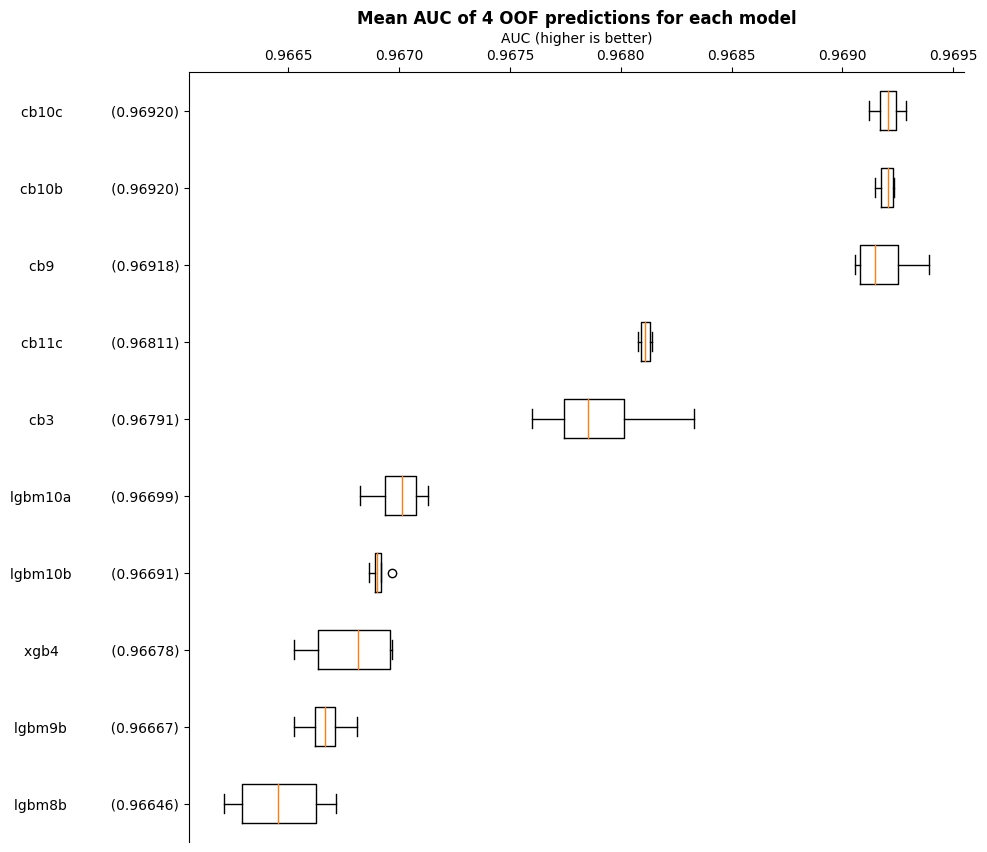

In [21]:
all_scores = {}

for r in range(n_repeats):
    for m in models:
        if r == 0:
            all_scores[m] = []
        all_scores[m].append(score_(train[target], oofs[r][m]))

all_scores = pd.DataFrame(all_scores)

for scs, ascending, lib, higher_ in zip([all_scores], [True], ["AUC"], ["higher"]):

    _col_order = list(scs.mean(axis=0).sort_values(ascending = ascending).index)
    _t = list(scs.mean(axis=0).sort_values(ascending = ascending).values)
    
    scs = scs[_col_order]
    _labels = [f"{l:15} ({v:.5f})" for l,v in zip(_col_order, _t)]

    fig, ax = plt.subplots(1, 1, figsize = (10, scs.shape[1]))
    ax.boxplot(scs, vert = False)
    ax.set_title(f"Mean {lib} of {n_repeats} OOF predictions for each model", fontweight = "bold")
    ax.set_xlabel(f"{lib} ({higher_} is better)")
    ax.set_yticklabels(_labels)
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position('top')
    ax.spines[["right", "bottom"]].set_visible(False)

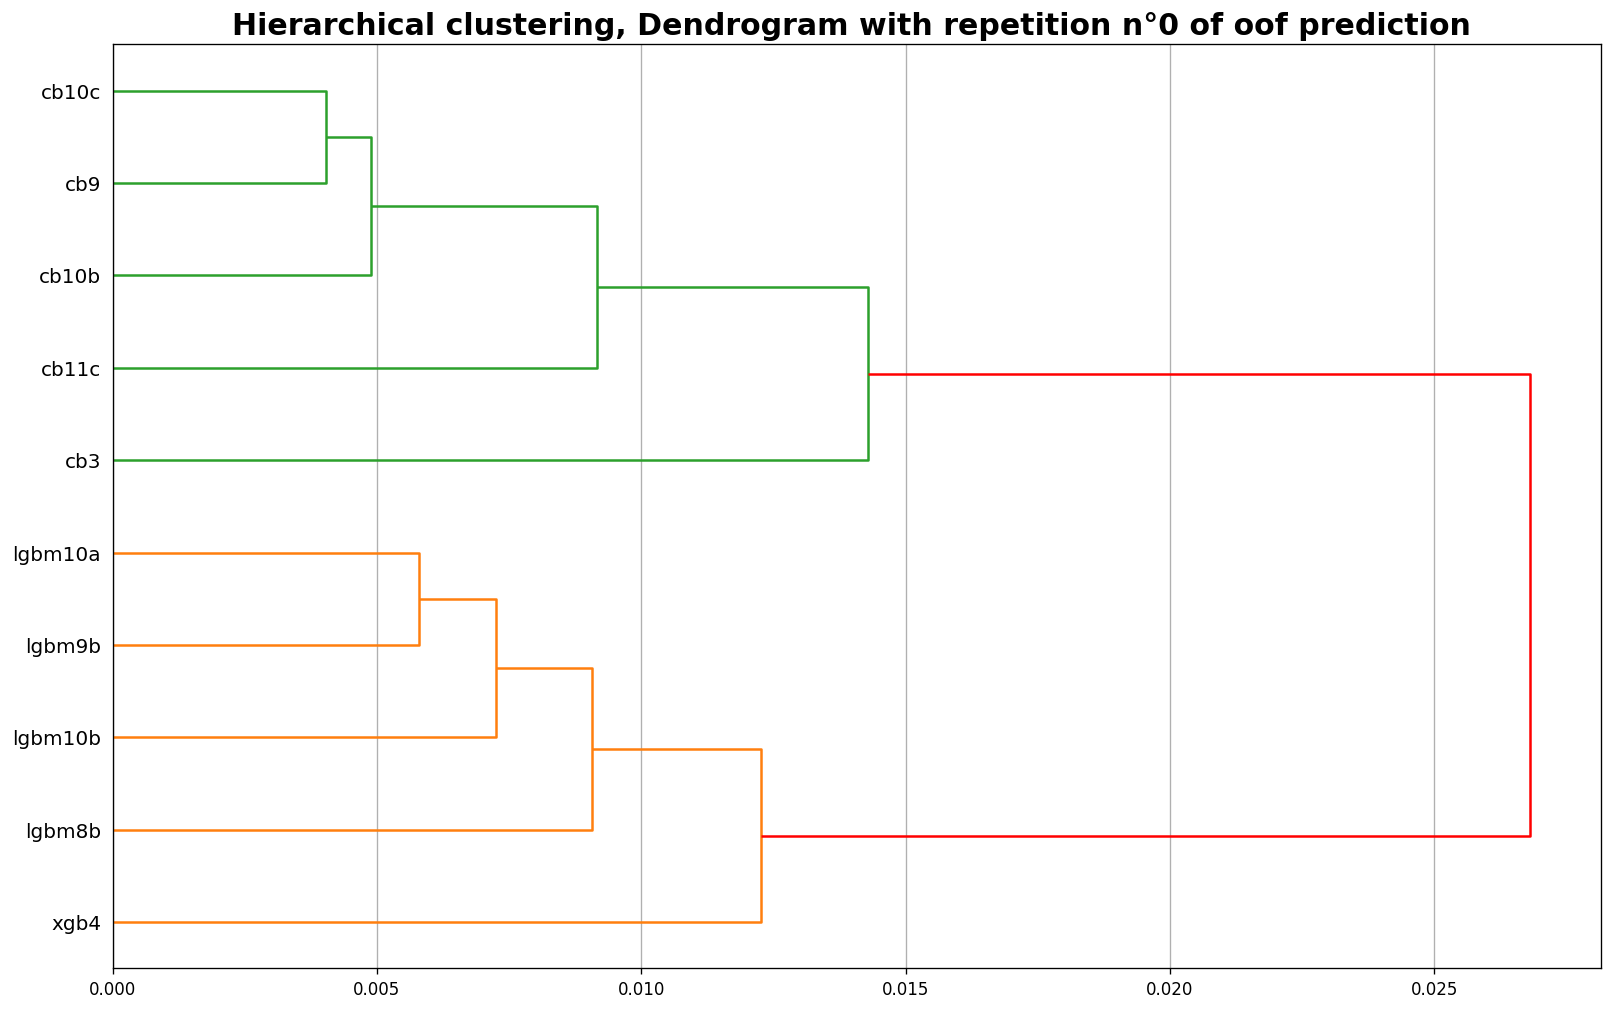

In [22]:
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

def hierarchical_clustering(data, title):
    
    fig, ax = plt.subplots(1, 1, figsize=(16, scs.shape[1]), dpi = 120)

    Z = linkage(squareform(1 - np.abs(data.corr())), 'complete')
    dn = dendrogram(Z, labels = data.columns, ax = ax, above_threshold_color = '#ff0000', orientation = 'right')

    hierarchy.set_link_color_palette(None)
    plt.grid(axis='x')
    plt.title(f'Hierarchical clustering, Dendrogram {title} ', fontsize = 18, fontweight = 'bold')
    plt.show()

hierarchical_clustering(oofs[0][models], title="with repetition n°0 of oof prediction")

## CV loop

In [23]:
def do_ensemble(train = train, target = target, models = models, cols = test.columns, test = test, 
                folds = StratifiedKFold(n_splits = n_splits, random_state = seed, shuffle = True), 
                my_model = None, digit = 6, lib_metric = "AUC", do_feat_imp = False,
               label = "pred", enc = None, split_with = target):
    
    feat_imp = FeatureImportance(n_permutations = 2, lib_metric = lib_metric)
    val_scores, trn_scores = [], []
    oofs = pd.Series(0.0, name = target, index = train.index)
    preds = pd.Series(0.0, name = target, index = test.index)
    intercept = []
    coefs = pd.DataFrame(0.0, index = cols, columns = [f"fold{i+1}" for i in range(folds.get_n_splits())])

    for fold, (trn_idx, val_idx) in enumerate(folds.split(train, train[split_with])):
        
        X_trn, y_trn = train.loc[trn_idx], train.loc[trn_idx, target]
        X_val, y_val = train.loc[val_idx], train.loc[val_idx, target]
            
        if (fold) % n_splits == 0:
            oof = pd.Series(0.0, name = target, index = train.index)
            pred = pd.Series(0.0, name = target, index = test.index)
        
        # Training
        my_model.fit(enc.fit_transform(X_trn[cols]), y_trn)
        if isinstance(my_model, LogisticRegression):
            intercept.append(my_model.intercept_[0]) ; 
            coefs[[f"fold{fold+1}"]] += pd.DataFrame(my_model.coef_).T.values

        # Score & prediction
        trn_scores.append(score_(y_trn, my_model.predict_proba(enc.transform(X_trn[cols]))[:, 1]))
        oof.iloc[val_idx] += my_model.predict_proba(enc.transform(X_val[cols]))[:, 1]
        val_scores.append(score_(y_val, oof.iloc[val_idx]))
        oofs.iloc[val_idx] += oof.loc[val_idx]
        pred += my_model.predict_proba(enc.transform(test[cols]))[:, 1] / folds.get_n_splits()
            
        scores = []
        for m in models:
            scores.append(score_(y_val, X_val[m]))
        
        my_color = Green if np.max(scores) < val_scores[-1:][0] else LightRed
        print(f"    Fold {fold + 1:2} : {lib_metric} {val_scores[-1:][0]:.{digit}f} (Best {models[np.argmax(scores)]:7} : {my_color}{np.max(scores):.{digit}f}{end} - ", end='')
        my_color = Green if np.mean(scores) < val_scores[-1:][0] else LightRed
        print(f"mean : {my_color}{np.mean(scores):.{digit}f}{end})", end='')        
        print(f" | in train {trn_scores[-1:][0]:.{digit}f}", end='')
        print(f' | Overfitting {trn_scores[-1:][0] - val_scores[-1:][0]:.{digit}f}')
        if (fold + 1) % n_splits == 0:
            preds += pred
        
        # Feature importance
        if do_feat_imp:
            for m in cols:
                for i in range(feat_imp.n_permutations):
                    df = enc.transform(X_val[cols])
                    df[m] = pd.Series(np.random.permutation(df[m]), index=df.index).astype(X_val[m].dtypes)
                    feat_imp.append(m, score_(y_val, my_model.predict_proba(df[cols])[:, 1]), val_scores[-1:][0])
    # end of loop
    
    coefs = pd.concat([coefs, pd.DataFrame(intercept, index = coefs.columns, columns=["intercept"]).T], axis=0)
    
    scores = []
    for f in models:
        scores.append(score_(train[target], train[f]))
    scores_ = score_(train[target], oofs)
    print(f'#OOF {lib_metric} {bold_blue}{scores_:.{digit}f}{end}', end='')
    my_color = Green if np.max(scores) < scores_ else LightRed
    print(f' best was {my_color}{np.max(scores):.{digit}f}{end} - ', end='')
    my_color = Green if np.mean(scores) < scores_ else LightRed
    print(f'mean {my_color}{np.mean(scores):.{digit}f}{end} | ', end='')
    print(f'Mean {lib_metric} : {bold_blue}{np.mean(val_scores):.{digit}f}{end}({bold+Red}±{np.std(val_scores):.{digit}f}){end}) | ', end='')
    print(f'Overfitting : {np.mean(trn_scores)-np.mean(val_scores):.{digit}f}')
    
    oofs.to_csv(f"{output_path}/oof_proba_{label}.csv")
    preds.to_csv(f"{output_path}/pred_proba_{label}.csv")
    
    feat_imp.plot()
    
    return {"coefs":coefs, "oofs_score":scores_}

## First try

# Logistic Regression with  ['lgbm9b', 'lgbm8b', 'xgb4', 'lgbm10a', 'lgbm10b', 'cb3', 'cb9', 'cb10b', 'cb10c', 'cb11c']
    Fold  1 : AUC 0.962786 (Best cb10b   : 0.962221 - mean : 0.960449) | in train 0.970939 | Overfitting 0.008152
    Fold  2 : AUC 0.969327 (Best xgb4    : 0.967879 - mean : 0.967032) | in train 0.970487 | Overfitting 0.001160
    Fold  3 : AUC 0.971731 (Best lgbm9b  : 0.971275 - mean : 0.969913) | in train 0.970298 | Overfitting -0.001433
    Fold  4 : AUC 0.972499 (Best cb10b   : 0.972342 - mean : 0.969517) | in train 0.970284 | Overfitting -0.002215
    Fold  5 : AUC 0.968370 (Best cb10b   : 0.968767 - mean : 0.964794) | in train 0.970575 | Overfitting 0.002205
    Fold  6 : AUC 0.979578 (Best cb10b   : 0.980244 - mean : 0.976920) | in train 0.969744 | Overfitting -0.009834
    Fold  7 : AUC 0.970174 (Best cb3     : 0.971158 - mean : 0.967250) | in train 0.970414 | Overfitting 0.000240
    Fold  8 : AUC 0.969427 (Best cb9     : 0.968988 - mean : 0.967311) | in tra

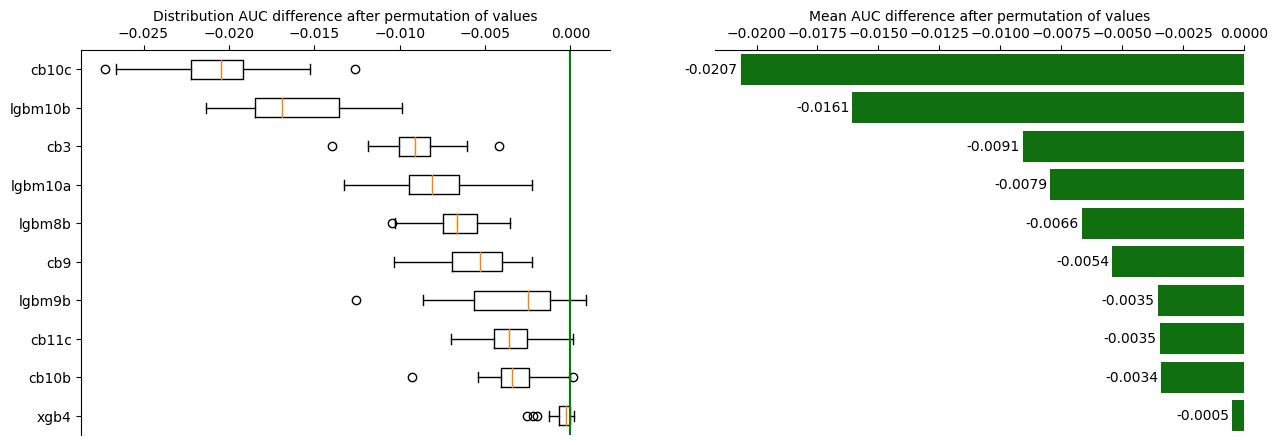

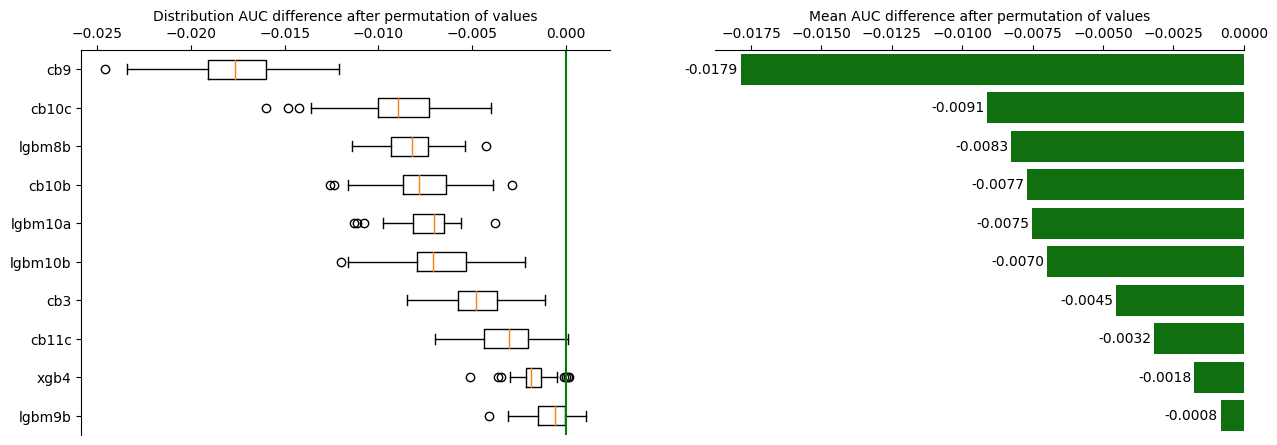

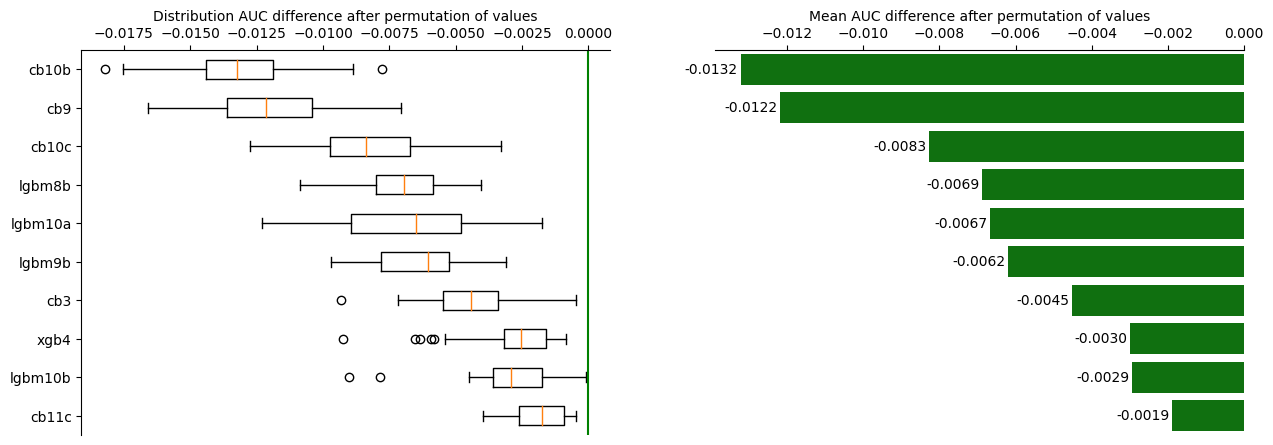

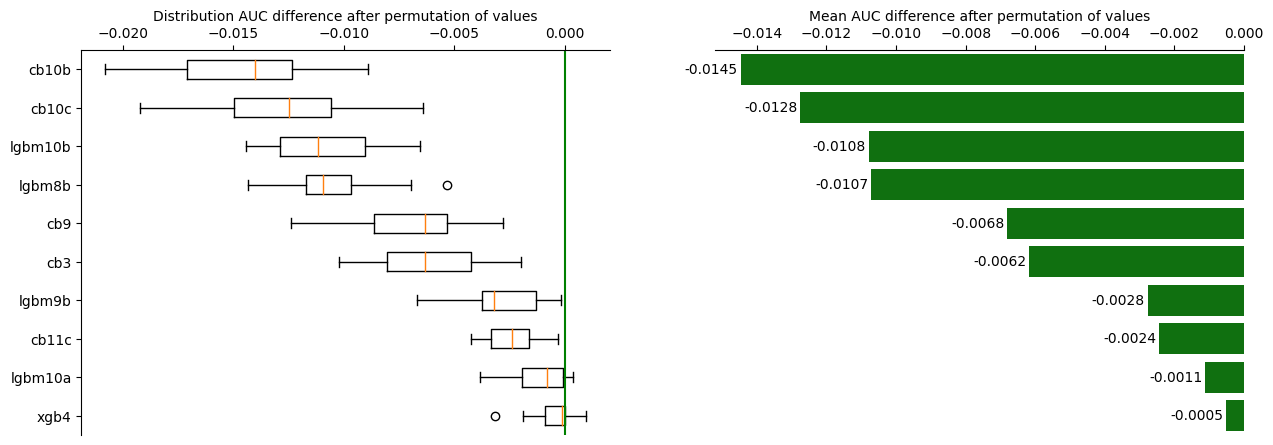

In [24]:
label, lib_metric, cols = 20241021, "AUC", ["lgbm9b", "lgbm8b", "xgb4", "lgbm10a", "lgbm10b", "cb3", "cb9", "cb10b", "cb10c", "cb11c"] 

print("# Logistic Regression with ", cols)

params = {"penalty": "l2", "C": 100, "random_state": seed, "fit_intercept" : True}

all_coefs, blend_scores = [], []

for r in range(n_repeats):
    
    oofs_ = oofs[0][[target]].copy() ; preds_ = pd.DataFrame(index = test.index)
    
    for c in models:
        oofs_[c] = oofs[r][c].copy()
        preds_[c] = preds[r][c].copy()

    lib_cols = []
    for c in cols:
        if isinstance(c, list):
            oofs_["_".join(c)] = oofs[r][c].mean(axis=1)
            preds_["_".join(c)] = preds[r][c].mean(axis=1)
            lib_cols.append("_".join(c))
        else:
            lib_cols.append(c)

    new_model = {
        "train"       : oofs_   , "test"        : preds_, 
        "cols"        : lib_cols, "models"      : models,
        "enc"         : MinMaxScaler(), #StandardScaler(),
        "my_model"    : LogisticRegression(**params), 
        "folds"       : StratifiedKFold(n_splits = n_splits, random_state = seed + +120 + r, shuffle = True),
        "split_with"  : target,  # <==
        "label"       : f"{label}_{r}",
    }
    
    res = do_ensemble(**new_model, do_feat_imp = True, lib_metric = lib_metric)
    all_coefs.append(res["coefs"])
    blend_scores.append(res["oofs_score"])
    
    # End of the loop
    
# Results
print(f"#{bold}Final mean {lib_metric} {bold_blue}{np.mean(blend_scores):.6f}", end='')
print(f"({LightRed}±{np.std(blend_scores):.5f}{end}) | ", end="")
print("Mean of : ", [f"{sc:.5f}" for sc in blend_scores])

all_oofs = pd.read_csv(f"{output_path}/oof_proba_{label}_0.csv", index_col='id')
for r in range(1, n_repeats):
    all_oofs += pd.read_csv(f"{output_path}/oof_proba_{label}_{r}.csv", index_col='id')
sc = roc_auc_score(train[target], all_oofs)
print(f'#{bold}Over OOF {lib_metric} for label {label} : {bold_blue}{sc:.6f}{end}')

## The less is the best

To reduce standard deviation of ensemble AUC : 

In [25]:
train["class_"] = 0
for n in range(n_repeats):
    train["class_"] += oofs[n]["cb9"] / n_repeats
train["class"] = pd.qcut(train["class_"], 10).astype(str) + "_" + train[target].astype(str)

rare_classes = train["class"].value_counts().index[-4:].values
print(f"Rare classes : {rare_classes}")
mask = train["class"].isin(rare_classes)
train.loc[mask, "class"] = "rare_1"

display(train["class"].value_counts())

for n in range(n_repeats):
    oofs[n]["class"] = train["class"]

Rare classes : ['(0.00548, 0.00894]_1' '(0.00309, 0.00548]_1' '(0.00141, 0.00309]_1'
 '(-0.0009874, 0.00141]_1']


class
(-0.0009874, 0.00141]_0    5864
(0.00141, 0.00309]_0       5857
(0.00309, 0.00548]_0       5853
(0.00548, 0.00894]_0       5828
(0.00894, 0.0147]_0        5810
(0.0147, 0.0256]_0         5765
(0.0256, 0.0504]_0         5683
(0.881, 1.0]_1             5629
(0.0504, 0.127]_0          5433
(0.127, 0.881]_0           3966
(0.127, 0.881]_1           1898
(0.0504, 0.127]_1           432
(0.881, 1.0]_0              236
(0.0256, 0.0504]_1          181
(0.0147, 0.0256]_1           99
rare_1                       56
(0.00894, 0.0147]_1          55
Name: count, dtype: int64

# Logistic Regression with  [['lgbm9b', 'lgbm8b'], 'xgb4', ['lgbm10a', 'lgbm10b'], ['cb3', 'cb9', 'cb10b', 'cb10c', 'cb11c']]
    Fold  1 : AUC 0.971183 (Best cb10c   : 0.969301 - mean : 0.968199) | in train 0.970490 | Overfitting -0.000693
    Fold  2 : AUC 0.970481 (Best cb9     : 0.969745 - mean : 0.967655) | in train 0.970520 | Overfitting 0.000039
    Fold  3 : AUC 0.970472 (Best cb3     : 0.969704 - mean : 0.967344) | in train 0.970543 | Overfitting 0.000071
    Fold  4 : AUC 0.971883 (Best cb9     : 0.969544 - mean : 0.968926) | in train 0.970432 | Overfitting -0.001451
    Fold  5 : AUC 0.970759 (Best cb10b   : 0.970127 - mean : 0.967643) | in train 0.970517 | Overfitting -0.000242
    Fold  6 : AUC 0.969431 (Best cb9     : 0.968369 - mean : 0.966628) | in train 0.970622 | Overfitting 0.001191
    Fold  7 : AUC 0.970339 (Best cb11c   : 0.969193 - mean : 0.967298) | in train 0.970536 | Overfitting 0.000197
    Fold  8 : AUC 0.971398 (Best cb10c   : 0.970481 - mean : 0.968696) | 

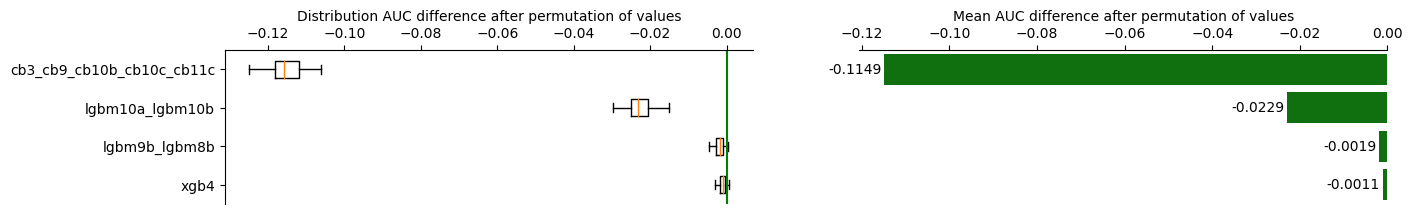

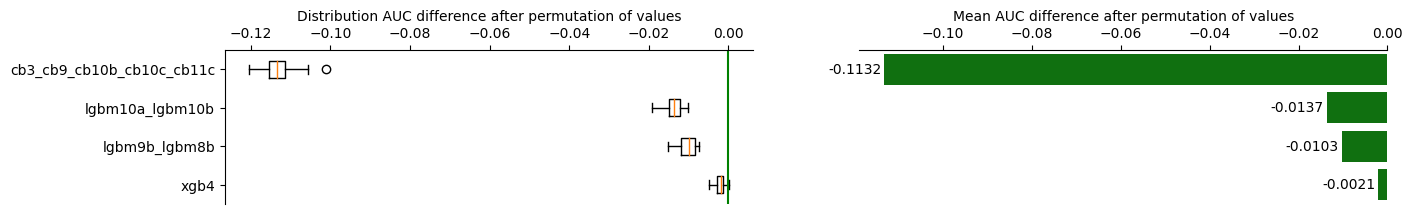

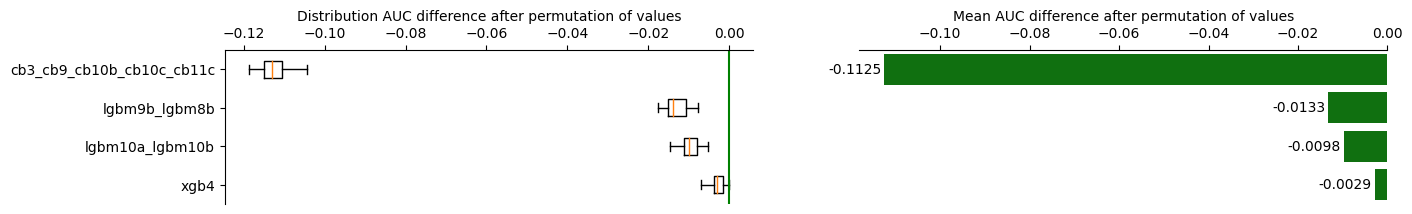

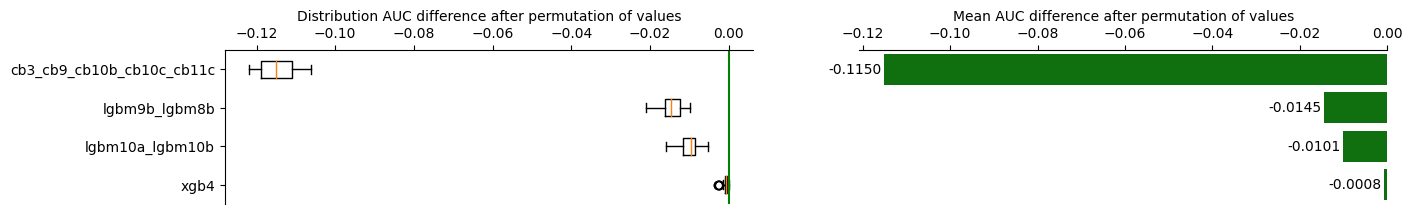

In [26]:
label, lib_metric, cols = "20241022", "AUC", [["lgbm9b", "lgbm8b"], "xgb4", ["lgbm10a", "lgbm10b"], ["cb3", "cb9", "cb10b", "cb10c", "cb11c"]] 

print("# Logistic Regression with ", cols)

params = {"penalty": "l2", "C": 100, "random_state": seed, "fit_intercept" : True}

all_coefs, blend_scores = [], []

for r in range(n_repeats):
    
    oofs_ = oofs[0][[target, "class"]].copy() ; preds_ = pd.DataFrame(index = test.index)
    
    for c in models:
        oofs_[c] = oofs[r][c].copy()
        preds_[c] = preds[r][c].copy()

    lib_cols = []
    for c in cols:
        if isinstance(c, list):
            oofs_["_".join(c)] = oofs[r][c].mean(axis=1)
            preds_["_".join(c)] = preds[r][c].mean(axis=1)
            lib_cols.append("_".join(c))
        else:
            lib_cols.append(c)

    new_model = {
        "train"       : oofs_   , "test"        : preds_, 
        "cols"        : lib_cols, "models"      : models,
        "enc"         : MinMaxScaler(), #StandardScaler(),
        "my_model"    : LogisticRegression(**params), 
        "folds"       : StratifiedKFold(n_splits = n_splits, random_state = seed + +120 + r, shuffle = True),
        "split_with"  : "class",  # <==
        "label"       : f"{label}_{r}",
    }
    
    res = do_ensemble(**new_model, do_feat_imp = True, lib_metric = lib_metric)
    all_coefs.append(res["coefs"])
    blend_scores.append(res["oofs_score"])
    
    # End of the loop
    
# Results
print(f"#{bold}Final mean {lib_metric} {bold_blue}{np.mean(blend_scores):.6f}", end='')
print(f"({LightRed}±{np.std(blend_scores):.5f}{end}) | ", end="")
print("Mean of : ", [f"{sc:.5f}" for sc in blend_scores])

all_oofs = pd.read_csv(f"{output_path}/oof_proba_{label}_0.csv", index_col='id')
for r in range(1, n_repeats):
    all_oofs += pd.read_csv(f"{output_path}/oof_proba_{label}_{r}.csv", index_col='id')
sc = roc_auc_score(train[target], all_oofs)
print(f'#{bold}Over OOF {lib_metric} for label {label} : {bold_blue}{sc:.6f}{end}')

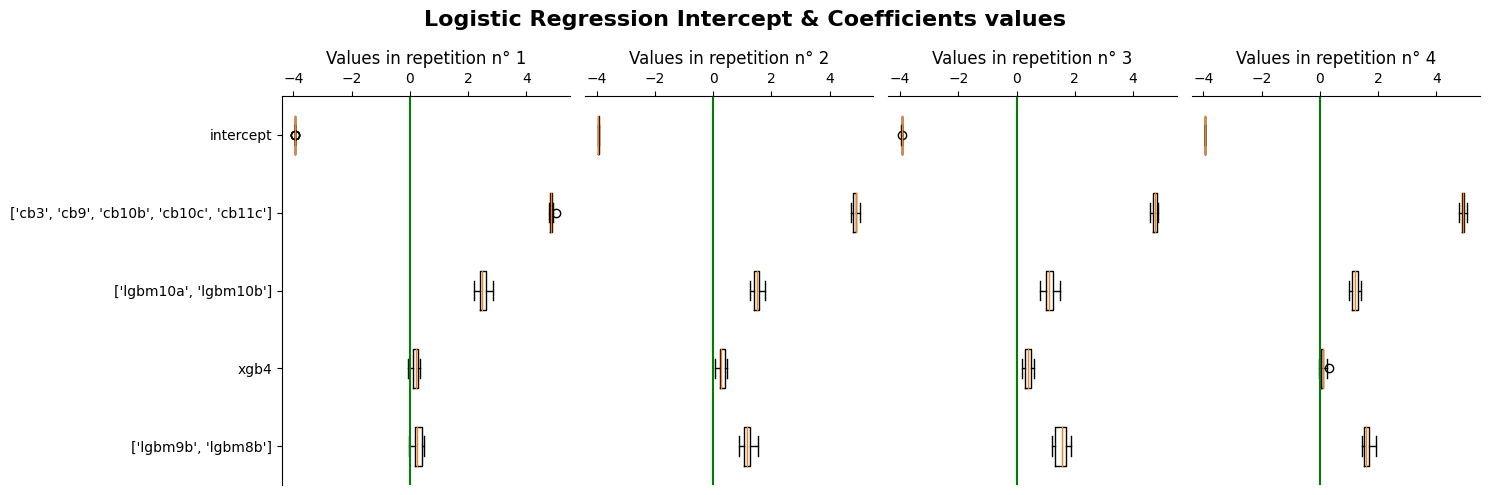

In [27]:
fig, ax = plt.subplots(1, n_repeats, 
                       figsize = (15, int(all_coefs[0].shape[0])), 
                       sharex = True, tight_layout = True)
fig.suptitle("Logistic Regression Intercept & Coefficients values", fontweight = "bold", fontsize = 16)

for i in range(n_repeats):
    ax[i].boxplot(all_coefs[i][[f"fold{f+1}" for f in range(n_splits)]].T, vert = False)
    ax[i].set_yticklabels(cols+["intercept"])
    ax[i].set_title(f"Values in repetition n° {i+1}")
    ax[i].axvline(x = 0, color = 'green')
    ax[i].xaxis.set_ticks_position("top")
    ax[i].xaxis.set_label_position('top')
    ax[i].spines[["right", "bottom"]].set_visible(False)
    if i>0: 
        ax[i].spines[["left"]].set_visible(False)
        ax[i].set_yticks([])

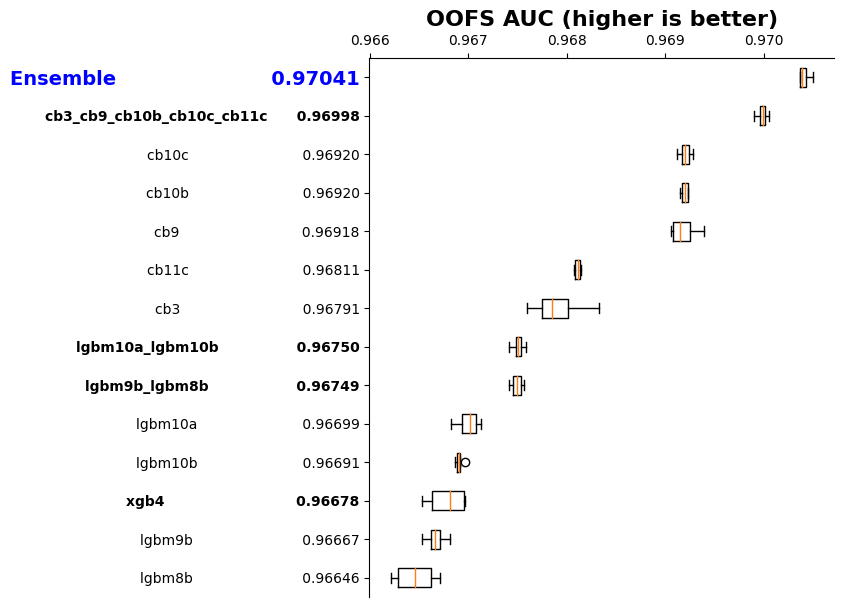

In [28]:
all_scores = {}
ascending = True
bolds_ = []
for r in range(n_repeats):
    for c in cols:
        if isinstance(c, list):
            for ci in c:
                if r == 0:
                    all_scores[ci] = []
                all_scores[ci].append(score_(train[target], oofs[r][ci]))
                if r == 0: bolds_.append(False)
            if r == 0:
                all_scores["_".join(c)] = []
            all_scores["_".join(c)].append(score_(train[target], oofs[r][c].mean(axis=1)))
            if r == 0: bolds_.append(True)
        else:
            if r == 0:
                all_scores[c] = []
            all_scores[c].append(score_(train[target], oofs[r][c]))
            if r == 0: bolds_.append(True)
        
all_scores["Ensemble"] = blend_scores
bolds_.append(True)


# Store them in a dataframe and sorted lists
all_scores = pd.DataFrame(all_scores)

_col_order = [x for _, x in sorted(zip(all_scores.mean(axis=0).values, list(all_scores.mean(axis=0).index)))]
bolds = [x for _, x in sorted(zip(all_scores.mean(axis=0).values, bolds_))]
all_scores = all_scores[_col_order]

_t = list(all_scores.mean(axis=0).sort_values(ascending = ascending).values)
_labels = [f"{l:30} {v:.5f}" for l,v in zip(_col_order, _t)]


# Plot
_, ax = plt.subplots(1, 1, figsize = (6, int(all_scores.shape[1] * 1/2)))

ax.boxplot(all_scores, vert = False)
ax.set_yticklabels(_labels)

for i, v in enumerate(bolds):
    if v:
        plt.setp(ax.get_yticklabels()[i], weight = "bold")
plt.setp(ax.get_yticklabels()[-1:], color = 'blue', size = 14, weight = "bold")
    
ax.set_title("OOFS AUC (higher is better)", fontweight = "bold", fontsize = 16)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position('top')
ax.spines[["right", "bottom"]].set_visible(False)

# Submission

## Training for each repeatition with all samples

In [29]:
y_trn_pred = pd.Series(0, index = train.index, name = target)
y_pred = pd.Series(0, index = test.index, name = target)
    
for r in range(n_repeats):
    X, Xp = pd.DataFrame(index = train.index), pd.DataFrame(index = test.index)
    for c in cols:
        if isinstance(c, list):
            X["_".join(c)] = oofs[r][c].mean(axis=1)
            Xp["_".join(c)] = preds[r][c].mean(axis=1)
        else:
            X[c] = oofs[r][c].values
            Xp[c] = preds[r][c].values

    my_model = make_pipeline(MinMaxScaler(), LogisticRegression(**params))
    my_model.fit(X[lib_cols], train[target])
    y_trn_pred += my_model.predict_proba(X[lib_cols])[:, 1]
    y_pred += my_model.predict_proba(Xp[lib_cols])[:, 1] / n_repeats
    print(f"  AUC in repeatition n°{r+1} : {score_(train[target], my_model.predict_proba(X[lib_cols])[:, 1]):.6f}")
    
print(f"AUC for mean predictions : {score_(train[target], y_trn_pred):.6f}")

  AUC in repeatition n°1 : 0.970526
  AUC in repeatition n°2 : 0.970420
  AUC in repeatition n°3 : 0.970446
  AUC in repeatition n°4 : 0.970383
AUC for mean predictions : 0.970543


## Training with mean of all the samples

In [30]:
X, Xp = pd.DataFrame(index = train.index), pd.DataFrame(index = test.index)

for c in cols:
    if isinstance(c, list):
        X["_".join(c)] = 0 ; Xp["_".join(c)] = 0
        for r in range(n_repeats):
            X["_".join(c)] += oofs[r][c].mean(axis=1)
            Xp["_".join(c)] += preds[r][c].mean(axis=1)
    else:
        X[c] = 0 ; Xp[c] = 0
        for r in range(n_repeats):
            X[c] += oofs[r][c].values
            Xp[c] += preds[r][c].values

my_model = make_pipeline(MinMaxScaler(), LogisticRegression(**params))
my_model.fit(X[lib_cols], train[target])

y_trn_pred = my_model.predict_proba(X[lib_cols])[:, 1]
print(f"{lib_metric} : {score_(train[target], y_trn_pred):.6f}")
pd.Series(my_model.predict_proba(Xp[lib_cols])[:, 1], index = test.index, name = target).to_csv(f"submission.csv")
pd.read_csv('submission.csv').head()

AUC : 0.970533


,id,loan_status
0,58645,0.979840
1,58646,0.021342
2,58647,0.391197
3,58648,0.019998
4,58649,0.024592


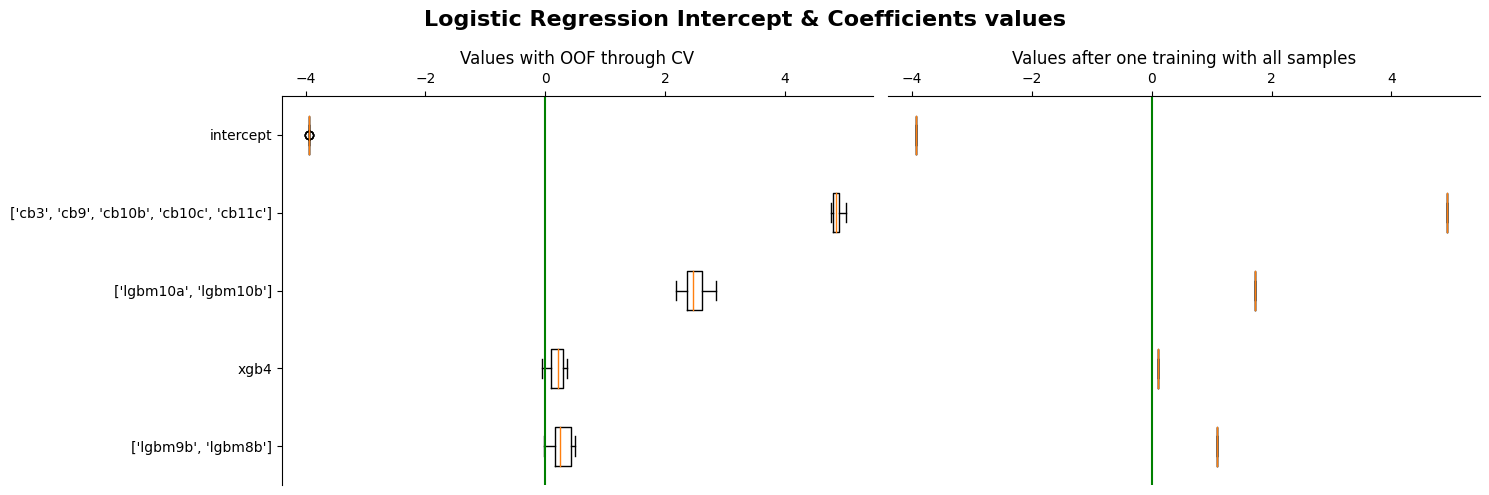

In [31]:
res = all_coefs[0][[f"fold{f+1}" for f in range(n_splits)]].T
for i in range(1, n_repeats):
    res = pd.concat([res, all_coefs[0][[f"fold{f+1}" for f in range(n_splits)]].T], axis=0)

fig, ax = plt.subplots(1, 2, 
                       figsize = (15, int(res.shape[1])), 
                       sharex = True, tight_layout = True)
fig.suptitle("Logistic Regression Intercept & Coefficients values", fontweight = "bold", fontsize = 16)

ax[0].boxplot(res, vert = False)
ax[1].boxplot(pd.Series(my_model[1].coef_.tolist()[0] + list(my_model[1].intercept_), index=res.columns).
              to_frame().T, vert = False)
ax[0].set_title(f"Values with OOF through CV")
ax[1].set_title(f"Values after one training with all samples")
for i in range(2):
    ax[i].set_yticklabels(cols+["intercept"])
    ax[i].axvline(x = 0, color = 'green')
    ax[i].xaxis.set_ticks_position("top")
    ax[i].xaxis.set_label_position('top')
    ax[i].spines[["right", "bottom"]].set_visible(False)
    if i>0: 
        ax[i].spines[["left"]].set_visible(False)
        ax[i].set_yticks([])